In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

df = pd.read_csv("../data/raw/dataset.csv")
df.shape

(8950, 8)

In [16]:
df.head()

,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,C10001,40.900749,95.40,0.00,95.4,0.000000,1000.0,201.802084
1,C10002,3202.467416,0.00,0.00,0.0,6442.945483,7000.0,4103.032597
2,C10003,2495.148862,773.17,773.17,0.0,0.000000,7500.0,622.066742
3,C10004,1666.670542,1499.00,1499.00,0.0,205.788017,7500.0,0.000000
4,C10005,817.714335,16.00,16.00,0.0,0.000000,1200.0,678.334763


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CUST_ID                 8950 non-null   str    
 1   BALANCE                 8950 non-null   float64
 2   PURCHASES               8950 non-null   float64
 3   ONEOFF_PURCHASES        8950 non-null   float64
 4   INSTALLMENTS_PURCHASES  8950 non-null   float64
 5   CASH_ADVANCE            8950 non-null   float64
 6   CREDIT_LIMIT            8949 non-null   float64
 7   PAYMENTS                8950 non-null   float64
dtypes: float64(7), str(1)
memory usage: 611.9 KB


In [18]:
df.shape

(8950, 8)

In [19]:
df.describe()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000
mean,1564.474828,1003.204834,592.437371,411.067645,978.871112,4494.449450,1733.143852
std,2081.531879,2136.634782,1659.887917,904.338115,2097.163877,3638.815725,2895.063757
min,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000
25%,128.281915,39.635000,0.000000,0.000000,0.000000,1600.000000,383.276166
50%,873.385231,361.280000,38.000000,89.000000,0.000000,3000.000000,856.901546
75%,2054.140036,1110.130000,577.405000,468.637500,1113.821139,6500.000000,1901.134317
max,19043.138560,49039.570000,40761.250000,22500.000000,47137.211760,30000.000000,50721.483360


## Messing Values

### Indentify

In [20]:
df.isnull().sum()

CUST_ID                   0
BALANCE                   0
PURCHASES                 0
ONEOFF_PURCHASES          0
INSTALLMENTS_PURCHASES    0
CASH_ADVANCE              0
CREDIT_LIMIT              1
PAYMENTS                  0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
}).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
CREDIT_LIMIT,1,0.011173
CUST_ID,0,0.000000
PURCHASES,0,0.000000
BALANCE,0,0.000000
ONEOFF_PURCHASES,0,0.000000
INSTALLMENTS_PURCHASES,0,0.000000
CASH_ADVANCE,0,0.000000
PAYMENTS,0,0.000000


## Visualization

In [23]:

numeric_cols = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
                 "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

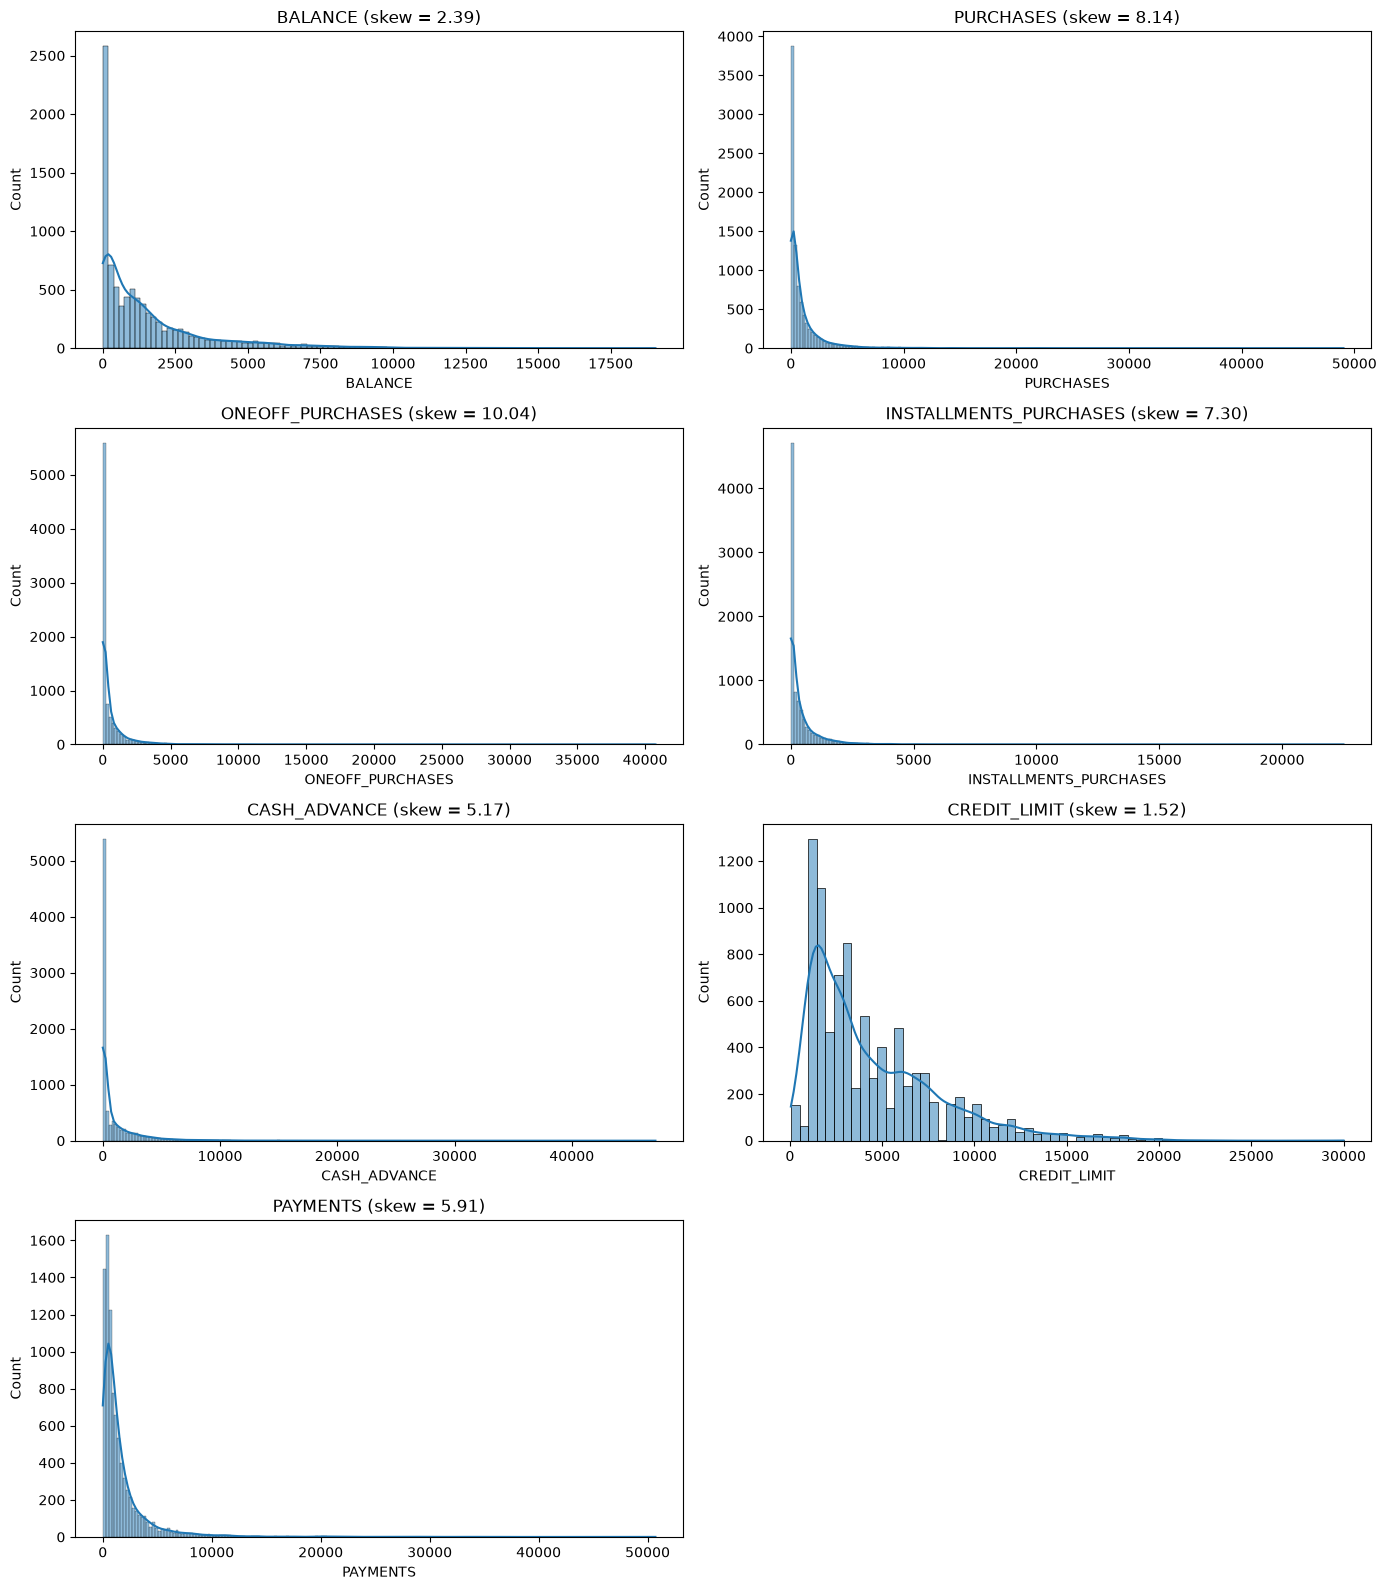

In [25]:

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    col_skew = skew(df[col].dropna())
    axes[i].set_title(f"{col} (skew = {col_skew:.2f})")

axes[7].axis("off")

plt.tight_layout()
plt.show()

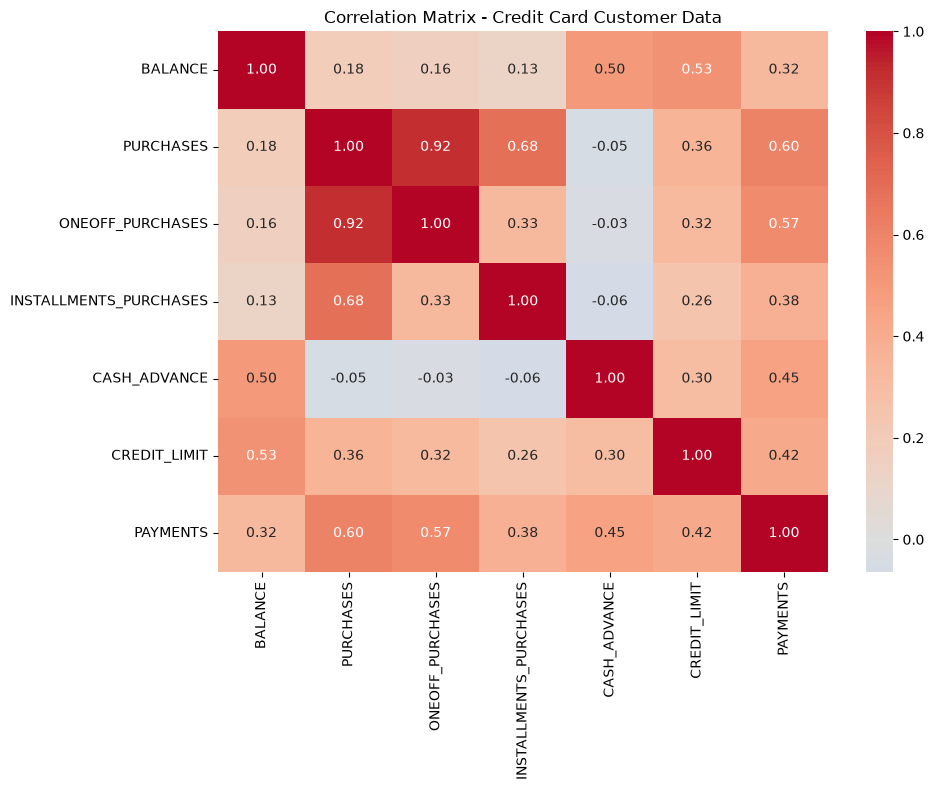

In [26]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Credit Card Customer Data")
plt.tight_layout()
plt.show()

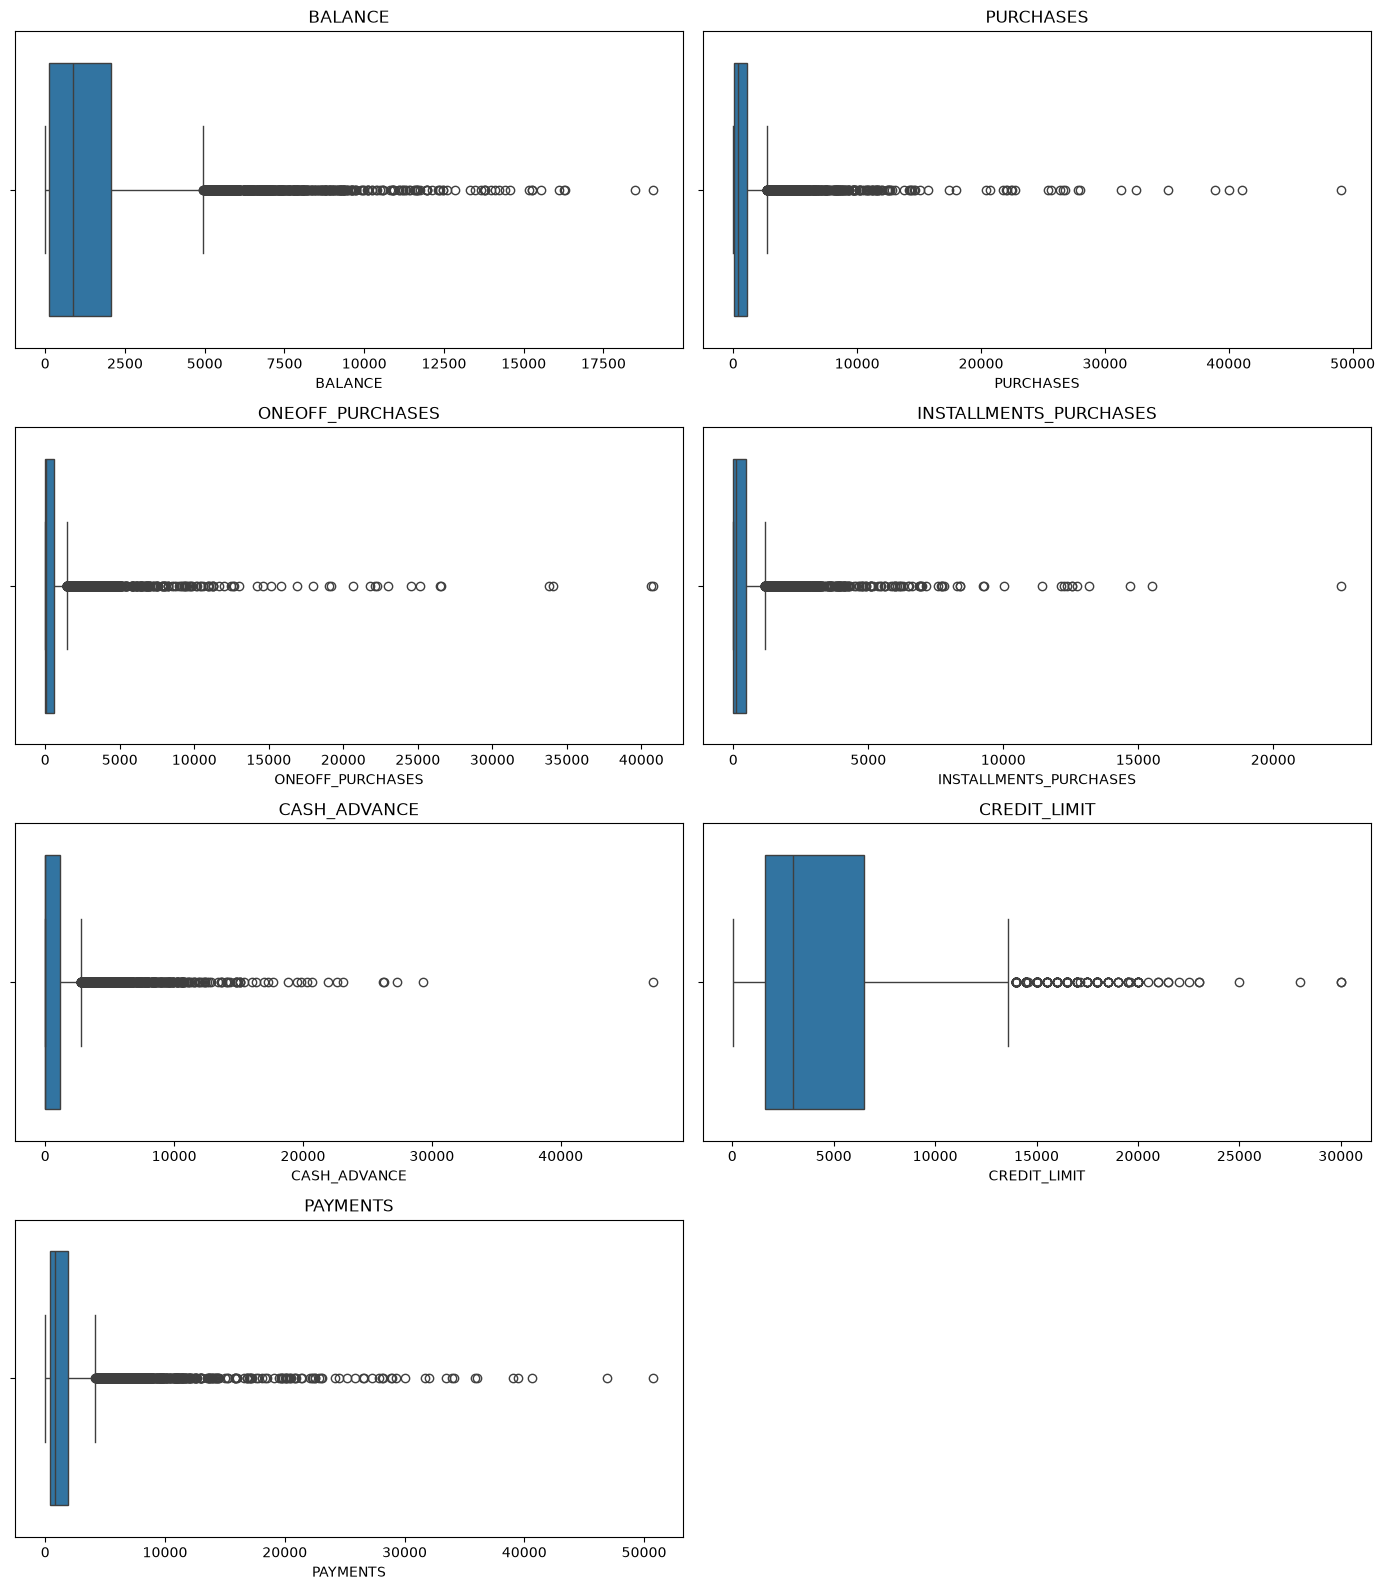

In [27]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

axes[7].axis("off")
plt.tight_layout()
plt.show()